<a href="https://colab.research.google.com/github/darcor99/pneumonia_classification/blob/main/pneumonia_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pneumonia Classification from Chest X-Ray Images

This notebook trains a ResNet18 model to classify chest X-rays into:
- BACTERIAL_PNEUMONIA
- NORMAL
- VIRAL_PNEUMONIA

**Instructions:**
1. Go to Runtime > Change runtime type > Select GPU (T4)
2. Upload your dataset zip file when prompted
3. Run all cells

In [ ]:
# Check GPU availability
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.9.0+cu126
CUDA available: True
GPU: Tesla T4


In [ ]:
# Upload and extract dataset
from google.colab import files
import zipfile
import os

print("Please upload your chest-x-ray-dataset-for-pneumonia-classification.zip file")
uploaded = files.upload()

# Extract the zip file
zip_filename = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall('/content/data')

print("\nExtracted contents:")
!ls -la /content/data/

Please upload your chest-x-ray-dataset-for-pneumonia-classification.zip file


Saving chest-x-ray-dataset-for-pneumonia-classification.zip to chest-x-ray-dataset-for-pneumonia-classification.zip

Extracted contents:
total 16
drwxr-xr-x 4 root root 4096 Jan 20 23:30 .
drwxr-xr-x 1 root root 4096 Jan 20 23:30 ..
drwxr-xr-x 5 root root 4096 Jan 20 23:30 test
drwxr-xr-x 5 root root 4096 Jan 20 23:30 train


In [ ]:
# Set data directories (adjust if your zip structure is different)
import os

# Find train and test directories
DATA_DIR = '/content/data'
for root, dirs, files in os.walk(DATA_DIR):
    if 'train' in dirs and 'test' in dirs:
        DATA_DIR = root
        break

TRAIN_DIR = os.path.join(DATA_DIR, 'train')
TEST_DIR = os.path.join(DATA_DIR, 'test')

print(f"Train directory: {TRAIN_DIR}")
print(f"Test directory: {TEST_DIR}")
print(f"\nClasses: {os.listdir(TRAIN_DIR)}")

Train directory: /content/data/train
Test directory: /content/data/test

Classes: ['VIRAL_PNEUMONIA', 'NORMAL', 'BACTERIAL_PNEUMONIA']


In [ ]:
# Configuration
BATCH_SIZE = 32
NUM_EPOCHS = 10
LEARNING_RATE = 0.001
NUM_CLASSES = 3
IMAGE_SIZE = 224

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# Imports and data loading
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Data transforms
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

# Load datasets
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                         shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                        shuffle=False, num_workers=2, pin_memory=True)

classes = train_dataset.classes
print(f"Classes: {classes}")
print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Classes: ['BACTERIAL_PNEUMONIA', 'NORMAL', 'VIRAL_PNEUMONIA']
Training samples: 15618
Test samples: 618


In [ ]:
# Create model
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Freeze early layers
for param in list(model.parameters())[:-10]:
    param.requires_grad = False

# Replace final layer
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_features, NUM_CLASSES)
)

model = model.to(device)
print("Model created: ResNet18 (pretrained, fine-tuned)")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 126MB/s]


Model created: ResNet18 (pretrained, fine-tuned)


In [ ]:
# Loss function with class weights for imbalanced data
class_counts = [7560, 4044, 4014]  # BACTERIAL, NORMAL, VIRAL
weights = torch.FloatTensor([1.0/c for c in class_counts])
weights = weights / weights.sum() * len(class_counts)
criterion = nn.CrossEntropyLoss(weight=weights.to(device))

# Optimizer and scheduler
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                      lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

In [ ]:
# Training functions
def train_epoch(model, train_loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(train_loader, desc="Training")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        pbar.set_postfix({
            'loss': f'{running_loss/total:.4f}',
            'acc': f'{100.*correct/total:.2f}%'
        })

    return running_loss / len(train_loader), 100. * correct / total


def evaluate(model, test_loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Evaluating"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100. * correct / total
    avg_loss = running_loss / len(test_loader)

    return avg_loss, accuracy, np.array(all_predictions), np.array(all_labels)

In [ ]:
# Training loop
print("="*60)
print("Starting Training")
print("="*60)

train_losses, train_accs = [], []
val_losses, val_accs = [], []
best_acc = 0.0

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 40)

    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # Evaluate
    val_loss, val_acc, _, _ = evaluate(model, test_loader, criterion)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_acc': best_acc,
            'classes': classes
        }, '/content/pneumonia_model.pth')
        print(f"Model saved (new best accuracy: {best_acc:.2f}%)")

    scheduler.step()

Starting Training

Epoch 1/10
----------------------------------------


Evaluating: 100%|██████████| 20/20 [00:01<00:00, 17.97it/s]


Train Loss: 0.5307, Train Acc: 74.30%
Val Loss: 1.2372, Val Acc: 67.48%
Model saved (new best accuracy: 67.48%)

Epoch 2/10
----------------------------------------


Evaluating: 100%|██████████| 20/20 [00:01<00:00, 17.74it/s]


Train Loss: 0.4533, Train Acc: 78.18%
Val Loss: 1.3600, Val Acc: 63.27%

Epoch 3/10
----------------------------------------


...

Train Loss: 0.2860, Train Acc: 86.53%
Val Loss: 1.6813, Val Acc: 62.14%

Epoch 9/10
----------------------------------------


Evaluating: 100%|██████████| 20/20 [00:01<00:00, 18.14it/s]


Train Loss: 0.2718, Train Acc: 87.28%
Val Loss: 2.1301, Val Acc: 54.69%

Epoch 10/10
----------------------------------------


Evaluating: 100%|██████████| 20/20 [00:01<00:00, 18.69it/s]

Train Loss: 0.2618, Train Acc: 87.91%
Val Loss: 1.4982, Val Acc: 63.92%


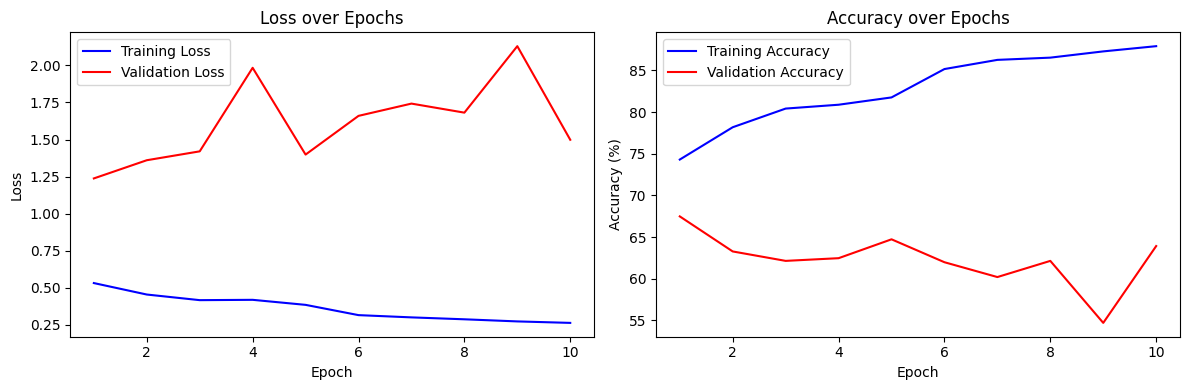

In [ ]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, len(train_losses) + 1)

ax1.plot(epochs, train_losses, 'b-', label='Training Loss')
ax1.plot(epochs, val_losses, 'r-', label='Validation Loss')
ax1.set_title('Loss over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(epochs, train_accs, 'b-', label='Training Accuracy')
ax2.plot(epochs, val_accs, 'r-', label='Validation Accuracy')
ax2.set_title('Accuracy over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Final evaluation
print("="*60)
print("Final Evaluation on Test Set")
print("="*60)

checkpoint = torch.load('/content/pneumonia_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])

_, final_acc, predictions, labels = evaluate(model, test_loader, criterion)

print(f"\nTest Accuracy: {final_acc:.2f}%")
print("\nClassification Report:")
print(classification_report(labels, predictions, target_names=classes))

Final Evaluation on Test Set


Evaluating: 100%|██████████| 20/20 [00:01<00:00, 18.08it/s]


Test Accuracy: 67.48%

Classification Report:
                     precision    recall  f1-score   support

BACTERIAL_PNEUMONIA       0.69      0.96      0.80       240
             NORMAL       0.97      0.32      0.48       231
    VIRAL_PNEUMONIA       0.55      0.77      0.64       147

           accuracy                           0.67       618
          macro avg       0.74      0.68      0.64       618
       weighted avg       0.76      0.67      0.64       618



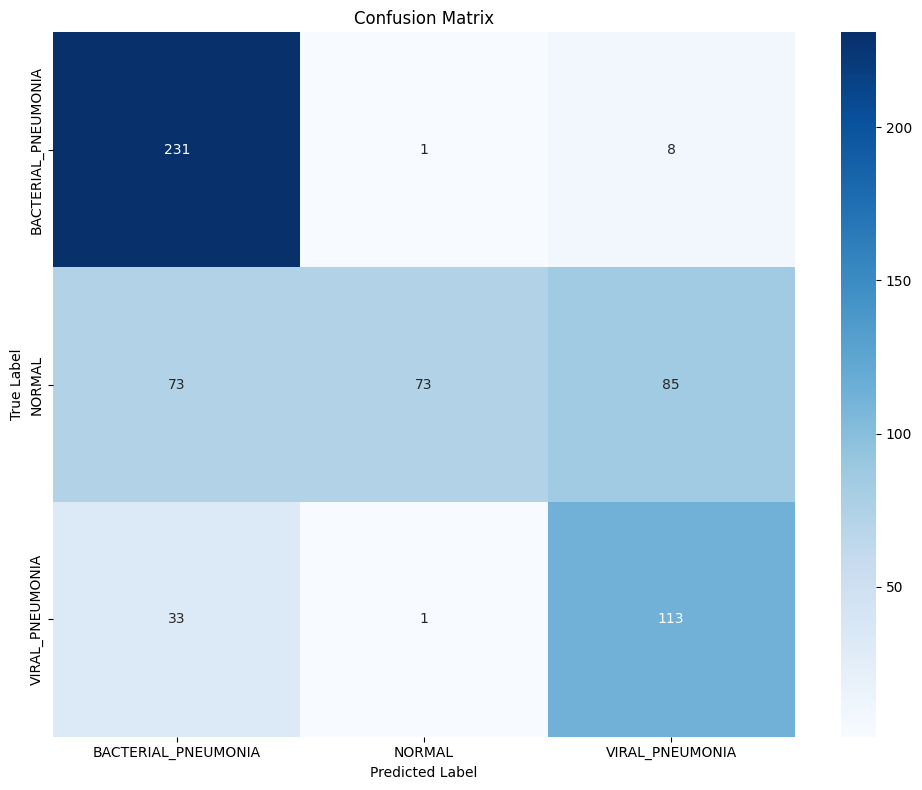

In [ ]:
# Confusion matrix
cm = confusion_matrix(labels, predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Model 2: Improved Architecture

Improvements over Model 1:
1. **Unfreeze layer4** - Allows deeper fine-tuning for X-ray specific features
2. **CosineAnnealingLR** - Smoother learning rate decay
3. **Early stopping** - Prevents overfitting, trains until convergence
4. **More epochs** - Up to 30 epochs (early stopping will halt if no improvement)
5. **Enhanced augmentation** (optional) - RandomAffine, RandomErasing, GaussianBlur
6. **MixUp** (optional) - Blends training images for better generalization
7. **Swappable architecture** - Easy to change from ResNet18 to other models

In [ ]:
# ============================================================
# MODEL 2 CONFIGURATION - Edit these settings as needed
# ============================================================

# Training settings
NUM_EPOCHS_V2 = 30
LEARNING_RATE_V2 = 0.001
EARLY_STOPPING_PATIENCE = 5

# ------------------------------------------------------------
# MODEL ARCHITECTURE SELECTION
# ------------------------------------------------------------
# Options: 'resnet18', 'resnet34', 'resnet50', 'efficientnet_b0',
#          'efficientnet_b3', 'densenet121', 'convnext_tiny'
MODEL_ARCHITECTURE = 'resnet18'

# ------------------------------------------------------------
# AUGMENTATION TOGGLES (set to True/False to enable/disable)
# ------------------------------------------------------------
USE_ENHANCED_AUGMENTATION = True   # RandomAffine, GaussianBlur
USE_RANDOM_ERASING = True          # Cutout-style regularization
USE_MIXUP = True                   # MixUp training
MIXUP_ALPHA = 0.2                  # MixUp interpolation strength (0.1-0.4 typical)

# ------------------------------------------------------------
# Store Model 1 results for comparison
model1_best_acc = best_acc
model1_train_losses = train_losses.copy()
model1_val_losses = val_losses.copy()
model1_train_accs = train_accs.copy()
model1_val_accs = val_accs.copy()
model1_predictions = predictions.copy()

# Print configuration
print(f"Model 1 best accuracy: {model1_best_acc:.2f}%")
print(f"\n{'='*60}")
print("MODEL 2 CONFIGURATION")
print(f"{'='*60}")
print(f"  Architecture:          {MODEL_ARCHITECTURE}")
print(f"  Max epochs:            {NUM_EPOCHS_V2}")
print(f"  Learning rate:         {LEARNING_RATE_V2}")
print(f"  Early stopping:        patience={EARLY_STOPPING_PATIENCE}")
print(f"\n  Enhanced augmentation: {'ON' if USE_ENHANCED_AUGMENTATION else 'OFF'}")
print(f"  Random erasing:        {'ON' if USE_RANDOM_ERASING else 'OFF'}")
print(f"  MixUp training:        {'ON' if USE_MIXUP else 'OFF'}" + (f" (alpha={MIXUP_ALPHA})" if USE_MIXUP else ""))
print(f"{'='*60}")

Model 1 best accuracy: 67.48%

MODEL 2 CONFIGURATION
  Architecture:          resnet18
  Max epochs:            30
  Learning rate:         0.001
  Early stopping:        patience=5

  Enhanced augmentation: ON
  Random erasing:        ON
  MixUp training:        ON (alpha=0.2)


In [ ]:
# ============================================================
# ENHANCED DATA AUGMENTATION & MIXUP FOR MODEL 2
# ============================================================

# Build transform list based on configuration
transform_list = [
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
]

# --- ENHANCED AUGMENTATION (comment out block to disable) ---
if USE_ENHANCED_AUGMENTATION:
    transform_list.extend([
        transforms.RandomAffine(
            degrees=15,
            translate=(0.1, 0.1),
            scale=(0.9, 1.1)
        ),
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    ])
    print("Enhanced augmentation: RandomAffine, GaussianBlur")

# Convert to tensor and normalize
transform_list.extend([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

# --- RANDOM ERASING (comment out block to disable) ---
if USE_RANDOM_ERASING:
    transform_list.append(
        transforms.RandomErasing(p=0.2, scale=(0.02, 0.2))  # Cutout-style
    )
    print("Random erasing: ON (p=0.2)")

# Create the enhanced transform
train_transform_v2 = transforms.Compose(transform_list)

# --- MIXUP IMPLEMENTATION ---
def mixup_data(x, y, alpha=0.2):
    """
    MixUp: Blends pairs of training images and their labels.
    Creates virtual training examples that improve generalization.

    Args:
        x: Input images (batch)
        y: Labels (batch)
        alpha: Beta distribution parameter (0.1-0.4 typical)

    Returns:
        mixed_x: Blended images
        y_a, y_b: Original labels for the pair
        lam: Mixing coefficient
    """
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)

    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam


def mixup_criterion(criterion, pred, y_a, y_b, lam):
    """Compute MixUp loss as weighted combination of two label losses."""
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


# --- TRAINING FUNCTION WITH MIXUP SUPPORT ---
def train_epoch_v2(model, train_loader, criterion, optimizer, use_mixup=False, mixup_alpha=0.2):
    """
    Training function with optional MixUp augmentation.

    Args:
        model: The model to train
        train_loader: DataLoader for training data
        criterion: Loss function
        optimizer: Optimizer
        use_mixup: Whether to use MixUp augmentation
        mixup_alpha: MixUp interpolation strength
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(train_loader, desc="Training")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        if use_mixup:
            # Apply MixUp
            images, labels_a, labels_b, lam = mixup_data(images, labels, mixup_alpha)

            optimizer.zero_grad()
            outputs = model(images)
            loss = mixup_criterion(criterion, outputs, labels_a, labels_b, lam)

            # For accuracy, use the dominant label
            _, predicted = outputs.max(1)
            correct += (lam * predicted.eq(labels_a).sum().item() +
                       (1 - lam) * predicted.eq(labels_b).sum().item())
        else:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        total += labels.size(0)

        pbar.set_postfix({
            'loss': f'{running_loss/len(pbar):.4f}',
            'acc': f'{100.*correct/total:.2f}%'
        })

    return running_loss / len(train_loader), 100. * correct / total


# Load datasets with enhanced transforms for Model 2
train_dataset_v2 = datasets.ImageFolder(TRAIN_DIR, transform=train_transform_v2)
train_loader_v2 = DataLoader(train_dataset_v2, batch_size=BATCH_SIZE,
                             shuffle=True, num_workers=2, pin_memory=True)

print(f"\nModel 2 training data loaded with enhanced transforms")
print(f"MixUp training: {'ON' if USE_MIXUP else 'OFF'}")

Enhanced augmentation: RandomAffine, GaussianBlur
Random erasing: ON (p=0.2)

Model 2 training data loaded with enhanced transforms
MixUp training: ON


In [ ]:
# ============================================================
# CREATE MODEL 2 - Supports multiple architectures
# ============================================================
# To change architecture: edit MODEL_ARCHITECTURE in the config cell above
# Supported: resnet18, resnet34, resnet50, efficientnet_b0, efficientnet_b3,
#            densenet121, convnext_tiny

def create_model_v2(architecture, num_classes, unfreeze_layers=True):
    """
    Create a pretrained model with custom classification head.

    Args:
        architecture: Model name (e.g., 'resnet18', 'efficientnet_b0')
        num_classes: Number of output classes
        unfreeze_layers: Whether to unfreeze later layers for fine-tuning

    Returns:
        model: The configured model
        model_name: Human-readable model name
    """

    # --- ResNet Family ---
    if architecture == 'resnet18':
        model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        num_features = model.fc.in_features
        if unfreeze_layers:
            for param in model.parameters():
                param.requires_grad = False
            for param in model.layer4.parameters():
                param.requires_grad = True
        model.fc = nn.Sequential(nn.Dropout(0.5), nn.Linear(num_features, num_classes))
        model_name = "ResNet18"

    elif architecture == 'resnet34':
        model = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)
        num_features = model.fc.in_features
        if unfreeze_layers:
            for param in model.parameters():
                param.requires_grad = False
            for param in model.layer4.parameters():
                param.requires_grad = True
        model.fc = nn.Sequential(nn.Dropout(0.5), nn.Linear(num_features, num_classes))
        model_name = "ResNet34"

    elif architecture == 'resnet50':
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        num_features = model.fc.in_features
        if unfreeze_layers:
            for param in model.parameters():
                param.requires_grad = False
            for param in model.layer4.parameters():
                param.requires_grad = True
        model.fc = nn.Sequential(nn.Dropout(0.5), nn.Linear(num_features, num_classes))
        model_name = "ResNet50"

    # --- EfficientNet Family ---
    elif architecture == 'efficientnet_b0':
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        num_features = model.classifier[1].in_features
        if unfreeze_layers:
            for param in model.parameters():
                param.requires_grad = False
            # Unfreeze last few blocks
            for param in model.features[-3:].parameters():
                param.requires_grad = True
        model.classifier = nn.Sequential(nn.Dropout(0.5), nn.Linear(num_features, num_classes))
        model_name = "EfficientNet-B0"

    elif architecture == 'efficientnet_b3':
        model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)
        num_features = model.classifier[1].in_features
        if unfreeze_layers:
            for param in model.parameters():
                param.requires_grad = False
            for param in model.features[-3:].parameters():
                param.requires_grad = True
        model.classifier = nn.Sequential(nn.Dropout(0.5), nn.Linear(num_features, num_classes))
        model_name = "EfficientNet-B3"

    # --- DenseNet ---
    elif architecture == 'densenet121':
        model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        num_features = model.classifier.in_features
        if unfreeze_layers:
            for param in model.parameters():
                param.requires_grad = False
            for param in model.features.denseblock4.parameters():
                param.requires_grad = True
        model.classifier = nn.Sequential(nn.Dropout(0.5), nn.Linear(num_features, num_classes))
        model_name = "DenseNet121"

    # --- ConvNeXt ---
    elif architecture == 'convnext_tiny':
        model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
        num_features = model.classifier[2].in_features
        if unfreeze_layers:
            for param in model.parameters():
                param.requires_grad = False
            for param in model.features[-1:].parameters():
                param.requires_grad = True
        model.classifier[2] = nn.Linear(num_features, num_classes)
        model_name = "ConvNeXt-Tiny"

    else:
        raise ValueError(f"Unknown architecture: {architecture}")

    return model, model_name


# Create the model
model2, model_name = create_model_v2(MODEL_ARCHITECTURE, NUM_CLASSES)
model2 = model2.to(device)

# Count trainable parameters
trainable_params = sum(p.numel() for p in model2.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model2.parameters())

print(f"Model 2 created: {model_name}")
print(f"Trainable parameters: {trainable_params:,} / {total_params:,} ({100*trainable_params/total_params:.1f}%)")
print(f"\nTo change architecture, edit MODEL_ARCHITECTURE in the config cell above.")

Model 2 created: ResNet18
Trainable parameters: 8,395,267 / 11,178,051 (75.1%)

To change architecture, edit MODEL_ARCHITECTURE in the config cell above.


In [ ]:
# Model 2 Loss, Optimizer, and Scheduler
# Using same weighted loss function
criterion2 = nn.CrossEntropyLoss(weight=weights.to(device))

# Optimizer for trainable parameters only
optimizer2 = optim.Adam(filter(lambda p: p.requires_grad, model2.parameters()),
                        lr=LEARNING_RATE_V2)

# CosineAnnealingLR - smoother learning rate decay
scheduler2 = optim.lr_scheduler.CosineAnnealingLR(optimizer2, T_max=NUM_EPOCHS_V2)

print("Optimizer: Adam")
print("Scheduler: CosineAnnealingLR (smoother decay than StepLR)")

Optimizer: Adam
Scheduler: CosineAnnealingLR (smoother decay than StepLR)


In [ ]:
# Model 2 Training Loop with Early Stopping + MixUp + Enhanced Augmentation
print("="*60)
print("Starting Model 2 Training")
print("="*60)
print(f"Architecture: {model_name}")
print(f"Enhanced augmentation: {'ON' if USE_ENHANCED_AUGMENTATION else 'OFF'}")
print(f"Random erasing: {'ON' if USE_RANDOM_ERASING else 'OFF'}")
print(f"MixUp: {'ON' if USE_MIXUP else 'OFF'}")
print("="*60)

train_losses_v2, train_accs_v2 = [], []
val_losses_v2, val_accs_v2 = [], []
best_acc_v2 = 0.0
no_improve_count = 0

for epoch in range(NUM_EPOCHS_V2):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS_V2}")
    print("-" * 40)

    # Train with enhanced loader and optional MixUp
    train_loss, train_acc = train_epoch_v2(
        model2,
        train_loader_v2,  # Uses enhanced transforms
        criterion2,
        optimizer2,
        use_mixup=USE_MIXUP,
        mixup_alpha=MIXUP_ALPHA
    )
    train_losses_v2.append(train_loss)
    train_accs_v2.append(train_acc)

    # Evaluate (always on clean test data)
    val_loss, val_acc, _, _ = evaluate(model2, test_loader, criterion2)
    val_losses_v2.append(val_loss)
    val_accs_v2.append(val_acc)

    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    print(f"Learning Rate: {scheduler2.get_last_lr()[0]:.6f}")

    # Save best model
    if val_acc > best_acc_v2:
        best_acc_v2 = val_acc
        no_improve_count = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model2.state_dict(),
            'optimizer_state_dict': optimizer2.state_dict(),
            'best_acc': best_acc_v2,
            'classes': classes,
            'architecture': MODEL_ARCHITECTURE
        }, '/content/pneumonia_model_v2.pth')
        print(f"Model saved (new best accuracy: {best_acc_v2:.2f}%)")
    else:
        no_improve_count += 1
        print(f"No improvement for {no_improve_count} epoch(s)")

    # Early stopping check
    if no_improve_count >= EARLY_STOPPING_PATIENCE:
        print(f"\nEarly stopping triggered after {epoch+1} epochs")
        break

    scheduler2.step()

print(f"\nTraining complete! Best accuracy: {best_acc_v2:.2f}%")

Starting Model 2 Training
Architecture: ResNet18
Enhanced augmentation: ON
Random erasing: ON
MixUp: ON

Epoch 1/30
----------------------------------------


Evaluating: 100%|██████████| 20/20 [00:01<00:00, 17.64it/s]


Train Loss: 0.6869, Train Acc: 68.49%
Val Loss: 1.1681, Val Acc: 52.27%
Learning Rate: 0.001000
Model saved (new best accuracy: 52.27%)

Epoch 2/30
----------------------------------------


Evaluating: 100%|██████████| 20/20 [00:01<00:00, 17.48it/s]


Train Loss: 0.6182, Train Acc: 72.31%
Val Loss: 0.9707, Val Acc: 65.70%
Learning Rate: 0.000997
Model saved (new best accuracy: 65.70%)

Epoch 3/30
----------------------------------------


...

Train Loss: 0.5005, Train Acc: 77.71%
Val Loss: 1.3023, Val Acc: 52.75%
Learning Rate: 0.000794
No improvement for 3 epoch(s)

Epoch 11/30
----------------------------------------


Evaluating: 100%|██████████| 20/20 [00:01<00:00, 17.27it/s]


Train Loss: 0.4889, Train Acc: 78.34%
Val Loss: 1.3415, Val Acc: 59.71%
Learning Rate: 0.000750
No improvement for 4 epoch(s)

Epoch 12/30
----------------------------------------


Evaluating: 100%|██████████| 20/20 [00:01<00:00, 17.53it/s]

Train Loss: 0.4979, Train Acc: 77.89%
Val Loss: 1.2321, Val Acc: 52.10%
Learning Rate: 0.000703
No improvement for 5 epoch(s)

Early stopping triggered after 12 epochs

Training complete! Best accuracy: 71.68%


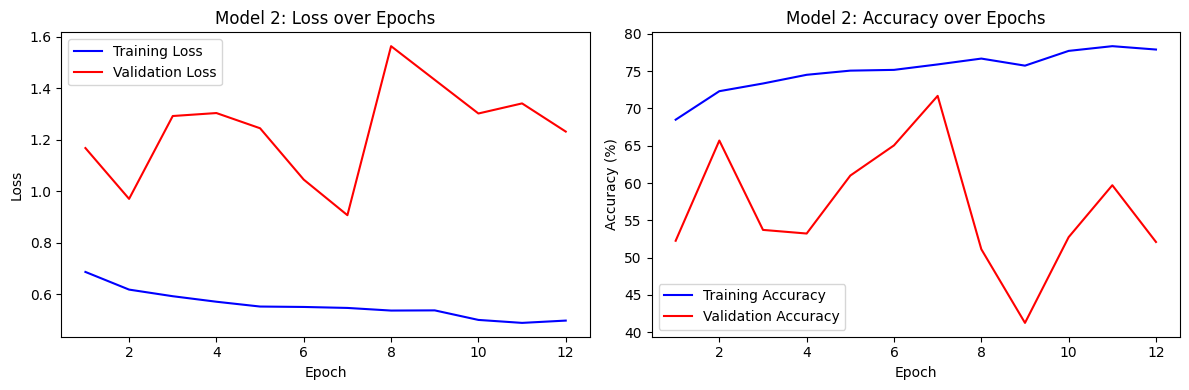

In [ ]:
# Plot Model 2 training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs_v2 = range(1, len(train_losses_v2) + 1)

ax1.plot(epochs_v2, train_losses_v2, 'b-', label='Training Loss')
ax1.plot(epochs_v2, val_losses_v2, 'r-', label='Validation Loss')
ax1.set_title('Model 2: Loss over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(epochs_v2, train_accs_v2, 'b-', label='Training Accuracy')
ax2.plot(epochs_v2, val_accs_v2, 'r-', label='Validation Accuracy')
ax2.set_title('Model 2: Accuracy over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Model 2 Final Evaluation
print("="*60)
print("Model 2 Final Evaluation on Test Set")
print("="*60)

checkpoint_v2 = torch.load('/content/pneumonia_model_v2.pth')
model2.load_state_dict(checkpoint_v2['model_state_dict'])

_, final_acc_v2, predictions_v2, labels_v2 = evaluate(model2, test_loader, criterion2)

print(f"\nTest Accuracy: {final_acc_v2:.2f}%")
print("\nClassification Report:")
print(classification_report(labels_v2, predictions_v2, target_names=classes))

Model 2 Final Evaluation on Test Set


Evaluating: 100%|██████████| 20/20 [00:01<00:00, 17.72it/s]



Test Accuracy: 71.68%

Classification Report:
                     precision    recall  f1-score   support

BACTERIAL_PNEUMONIA       0.82      0.97      0.89       240
             NORMAL       0.98      0.40      0.57       231
    VIRAL_PNEUMONIA       0.49      0.80      0.61       147

           accuracy                           0.72       618
          macro avg       0.76      0.72      0.69       618
       weighted avg       0.80      0.72      0.70       618



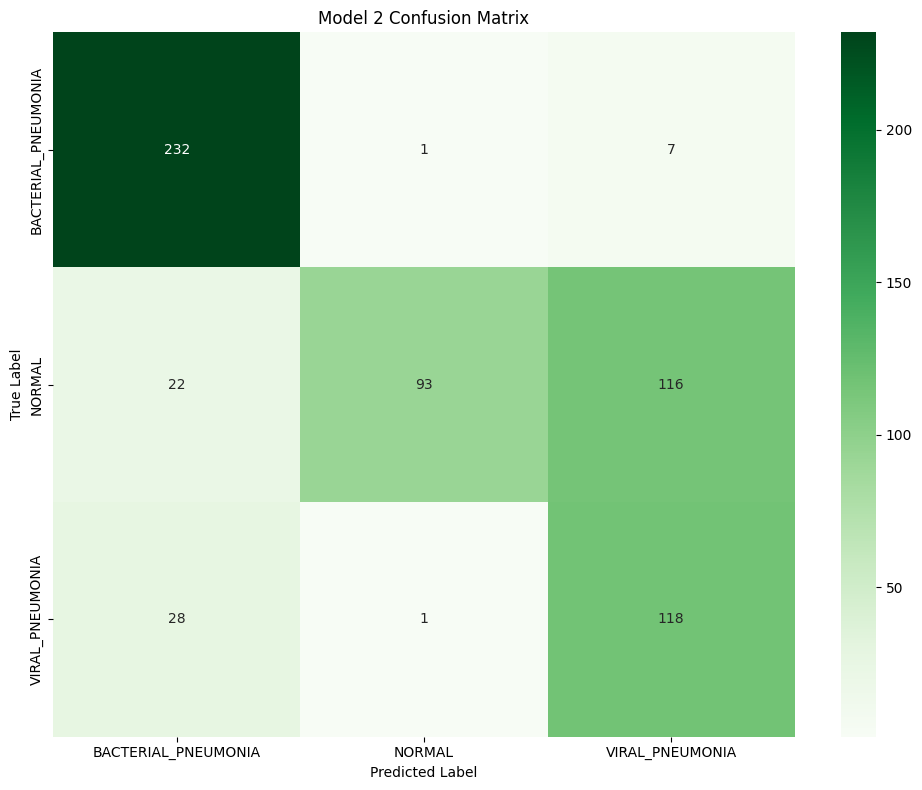

In [ ]:
# Model 2 Confusion Matrix
cm_v2 = confusion_matrix(labels_v2, predictions_v2)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_v2, annot=True, fmt='d', cmap='Greens',
            xticklabels=classes, yticklabels=classes)
plt.title('Model 2 Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Model 3: DenseNet121 (Medical Imaging Specialist)

DenseNet121 is particularly well-suited for medical imaging:
- **Proven track record** - Stanford's CheXNet used DenseNet121 for chest X-ray diagnosis
- **Dense connections** - Every layer receives features from all preceding layers
- **Parameter efficient** - Only 8M parameters but powerful feature extraction
- Uses same enhanced augmentation and MixUp as Model 2

In [ ]:
# ============================================================
# MODEL 3 CONFIGURATION - DenseNet121
# ============================================================

# Store Model 2 results for comparison
model2_best_acc = best_acc_v2
model2_train_losses = train_losses_v2.copy()
model2_val_losses = val_losses_v2.copy()
model2_train_accs = train_accs_v2.copy()
model2_val_accs = val_accs_v2.copy()
model2_predictions = predictions_v2.copy()
model2_architecture = MODEL_ARCHITECTURE

# Model 3 settings (same as Model 2, but with DenseNet121)
NUM_EPOCHS_V3 = 30
LEARNING_RATE_V3 = 0.001
EARLY_STOPPING_PATIENCE_V3 = 5

print(f"Model 2 ({model2_architecture}) best accuracy: {model2_best_acc:.2f}%")
print(f"\n{'='*60}")
print("MODEL 3 CONFIGURATION")
print(f"{'='*60}")
print(f"  Architecture:          DenseNet121")
print(f"  Max epochs:            {NUM_EPOCHS_V3}")
print(f"  Learning rate:         {LEARNING_RATE_V3}")
print(f"  Early stopping:        patience={EARLY_STOPPING_PATIENCE_V3}")
print(f"  Enhanced augmentation: {'ON' if USE_ENHANCED_AUGMENTATION else 'OFF'}")
print(f"  MixUp training:        {'ON' if USE_MIXUP else 'OFF'}")
print(f"{'='*60}")

Model 2 (resnet18) best accuracy: 71.68%

MODEL 3 CONFIGURATION
  Architecture:          DenseNet121
  Max epochs:            30
  Learning rate:         0.001
  Early stopping:        patience=5
  Enhanced augmentation: ON
  MixUp training:        ON


In [ ]:
# Create Model 3 - DenseNet121
model3, model3_name = create_model_v2('densenet121', NUM_CLASSES)
model3 = model3.to(device)

# Count trainable parameters
trainable_params_v3 = sum(p.numel() for p in model3.parameters() if p.requires_grad)
total_params_v3 = sum(p.numel() for p in model3.parameters())

print(f"Model 3 created: {model3_name}")
print(f"Trainable parameters: {trainable_params_v3:,} / {total_params_v3:,} ({100*trainable_params_v3/total_params_v3:.1f}%)")

# Loss, Optimizer, Scheduler
criterion3 = nn.CrossEntropyLoss(weight=weights.to(device))
optimizer3 = optim.Adam(filter(lambda p: p.requires_grad, model3.parameters()), lr=LEARNING_RATE_V3)
scheduler3 = optim.lr_scheduler.CosineAnnealingLR(optimizer3, T_max=NUM_EPOCHS_V3)

print("\nOptimizer: Adam")
print("Scheduler: CosineAnnealingLR")

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 183MB/s]


Model 3 created: DenseNet121
Trainable parameters: 2,161,155 / 6,956,931 (31.1%)

Optimizer: Adam
Scheduler: CosineAnnealingLR


In [ ]:
# Model 3 Training Loop
print("="*60)
print("Starting Model 3 Training (DenseNet121)")
print("="*60)
print(f"Enhanced augmentation: {'ON' if USE_ENHANCED_AUGMENTATION else 'OFF'}")
print(f"MixUp: {'ON' if USE_MIXUP else 'OFF'}")
print("="*60)

train_losses_v3, train_accs_v3 = [], []
val_losses_v3, val_accs_v3 = [], []
best_acc_v3 = 0.0
no_improve_count_v3 = 0

for epoch in range(NUM_EPOCHS_V3):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS_V3}")
    print("-" * 40)

    # Train with enhanced loader and MixUp
    train_loss, train_acc = train_epoch_v2(
        model3,
        train_loader_v2,
        criterion3,
        optimizer3,
        use_mixup=USE_MIXUP,
        mixup_alpha=MIXUP_ALPHA
    )
    train_losses_v3.append(train_loss)
    train_accs_v3.append(train_acc)

    # Evaluate
    val_loss, val_acc, _, _ = evaluate(model3, test_loader, criterion3)
    val_losses_v3.append(val_loss)
    val_accs_v3.append(val_acc)

    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    print(f"Learning Rate: {scheduler3.get_last_lr()[0]:.6f}")

    # Save best model
    if val_acc > best_acc_v3:
        best_acc_v3 = val_acc
        no_improve_count_v3 = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model3.state_dict(),
            'optimizer_state_dict': optimizer3.state_dict(),
            'best_acc': best_acc_v3,
            'classes': classes,
            'architecture': 'densenet121'
        }, '/content/pneumonia_model_v3.pth')
        print(f"Model saved (new best accuracy: {best_acc_v3:.2f}%)")
    else:
        no_improve_count_v3 += 1
        print(f"No improvement for {no_improve_count_v3} epoch(s)")

    # Early stopping
    if no_improve_count_v3 >= EARLY_STOPPING_PATIENCE_V3:
        print(f"\nEarly stopping triggered after {epoch+1} epochs")
        break

    scheduler3.step()

print(f"\nTraining complete! Best accuracy: {best_acc_v3:.2f}%")

Starting Model 3 Training (DenseNet121)
Enhanced augmentation: ON
MixUp: ON

Epoch 1/30
----------------------------------------


Evaluating: 100%|██████████| 20/20 [00:02<00:00,  9.24it/s]


Train Loss: 0.6968, Train Acc: 68.45%
Val Loss: 1.1072, Val Acc: 64.89%
Learning Rate: 0.001000
Model saved (new best accuracy: 64.89%)

Epoch 2/30
----------------------------------------


Evaluating: 100%|██████████| 20/20 [00:02<00:00,  9.50it/s]


Train Loss: 0.6371, Train Acc: 71.38%
Val Loss: 1.2099, Val Acc: 53.88%
Learning Rate: 0.000997
No improvement for 1 epoch(s)

Epoch 3/30
----------------------------------------


...

Train Loss: 0.6065, Train Acc: 72.88%
Val Loss: 1.1369, Val Acc: 58.41%
Learning Rate: 0.000976
No improvement for 3 epoch(s)

Epoch 5/30
----------------------------------------


Evaluating: 100%|██████████| 20/20 [00:02<00:00,  9.50it/s]


Train Loss: 0.5950, Train Acc: 73.09%
Val Loss: 1.0912, Val Acc: 61.49%
Learning Rate: 0.000957
No improvement for 4 epoch(s)

Epoch 6/30
----------------------------------------


Evaluating: 100%|██████████| 20/20 [00:02<00:00,  9.56it/s]

Train Loss: 0.5699, Train Acc: 74.42%
Val Loss: 1.2970, Val Acc: 58.41%
Learning Rate: 0.000933
No improvement for 5 epoch(s)

Early stopping triggered after 6 epochs

Training complete! Best accuracy: 64.89%


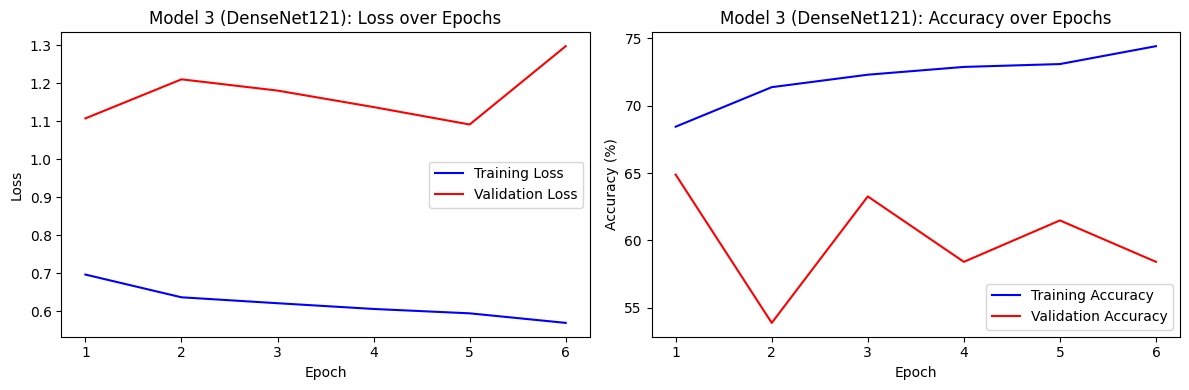

In [ ]:
# Plot Model 3 training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs_v3 = range(1, len(train_losses_v3) + 1)

ax1.plot(epochs_v3, train_losses_v3, 'b-', label='Training Loss')
ax1.plot(epochs_v3, val_losses_v3, 'r-', label='Validation Loss')
ax1.set_title('Model 3 (DenseNet121): Loss over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(epochs_v3, train_accs_v3, 'b-', label='Training Accuracy')
ax2.plot(epochs_v3, val_accs_v3, 'r-', label='Validation Accuracy')
ax2.set_title('Model 3 (DenseNet121): Accuracy over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Model 3 Final Evaluation
print("="*60)
print("Model 3 Final Evaluation on Test Set (DenseNet121)")
print("="*60)

checkpoint_v3 = torch.load('/content/pneumonia_model_v3.pth')
model3.load_state_dict(checkpoint_v3['model_state_dict'])

_, final_acc_v3, predictions_v3, labels_v3 = evaluate(model3, test_loader, criterion3)

print(f"\nTest Accuracy: {final_acc_v3:.2f}%")
print("\nClassification Report:")
print(classification_report(labels_v3, predictions_v3, target_names=classes))

Model 3 Final Evaluation on Test Set (DenseNet121)


Evaluating: 100%|██████████| 20/20 [00:02<00:00,  9.39it/s]


Test Accuracy: 64.89%

Classification Report:
                     precision    recall  f1-score   support

BACTERIAL_PNEUMONIA       0.90      0.83      0.87       240
             NORMAL       1.00      0.30      0.46       231
    VIRAL_PNEUMONIA       0.40      0.90      0.56       147

           accuracy                           0.65       618
          macro avg       0.77      0.68      0.63       618
       weighted avg       0.82      0.65      0.64       618



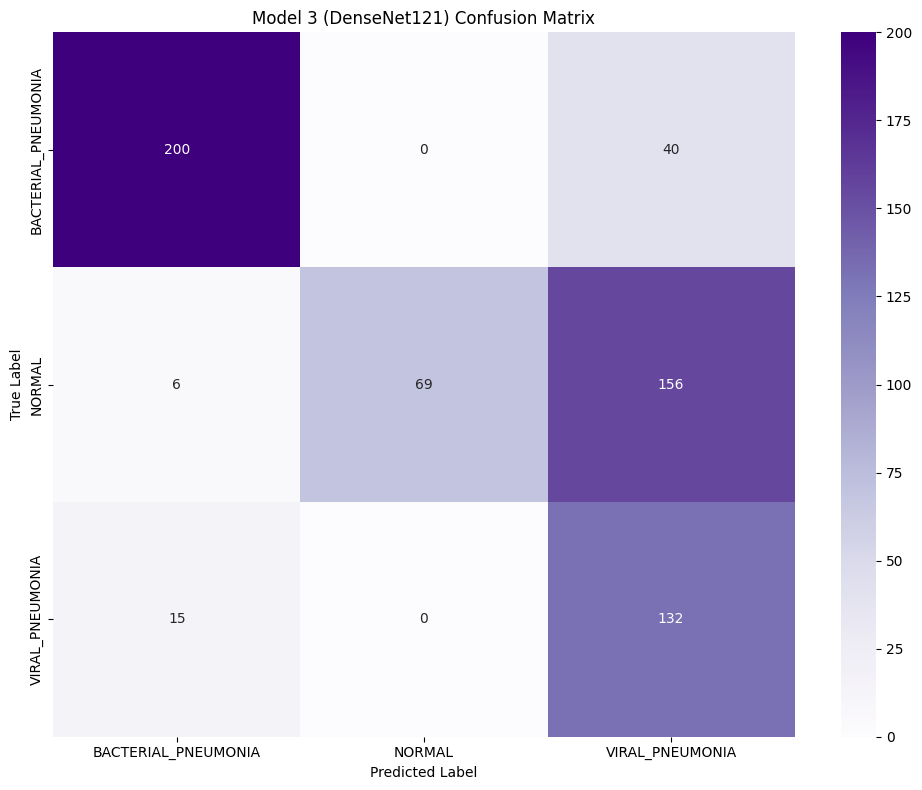

In [ ]:
# Model 3 Confusion Matrix
cm_v3 = confusion_matrix(labels_v3, predictions_v3)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_v3, annot=True, fmt='d', cmap='Purples',
            xticklabels=classes, yticklabels=classes)
plt.title('Model 3 (DenseNet121) Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Model Comparison

MODEL COMPARISON SUMMARY

Metric                    Model 1            Model 2            Model 3           
--------------------------------------------------------------------------------
Architecture              ResNet18           resnet18           DenseNet121       
Best Accuracy             67.48%             71.68%             64.89%
Epochs Trained            10                 12                 6                 
Scheduler                 StepLR             CosineAnnealing    CosineAnnealing   
Trainable Layers          Last 10 params     layer4 + fc        denseblock4 + fc  
Enhanced Augmentation     OFF                ON                 ON                
MixUp                     OFF                ON                 ON                


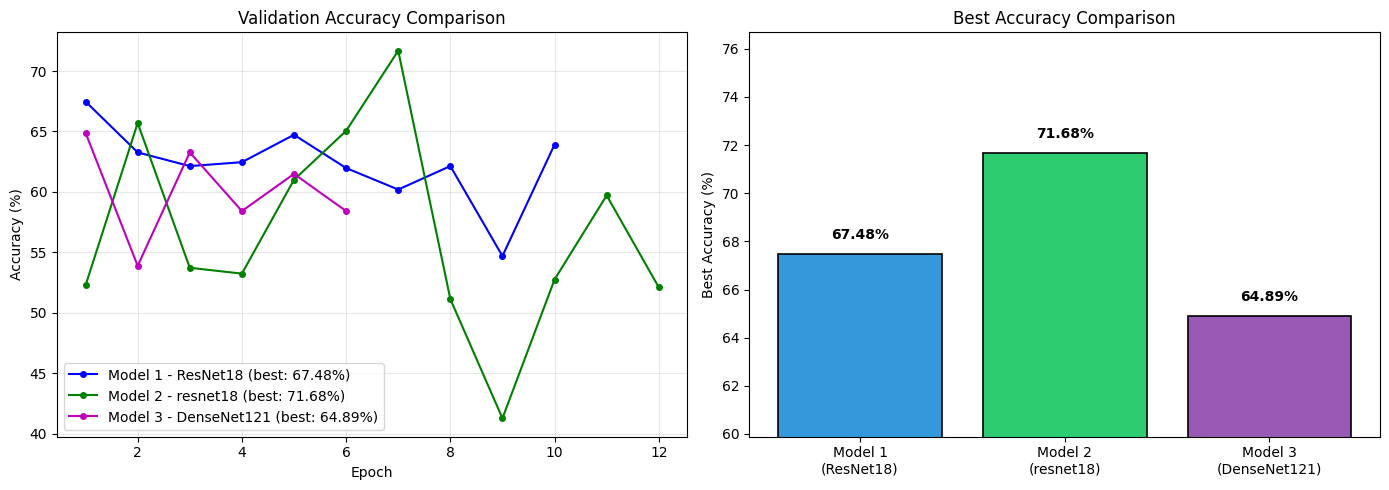

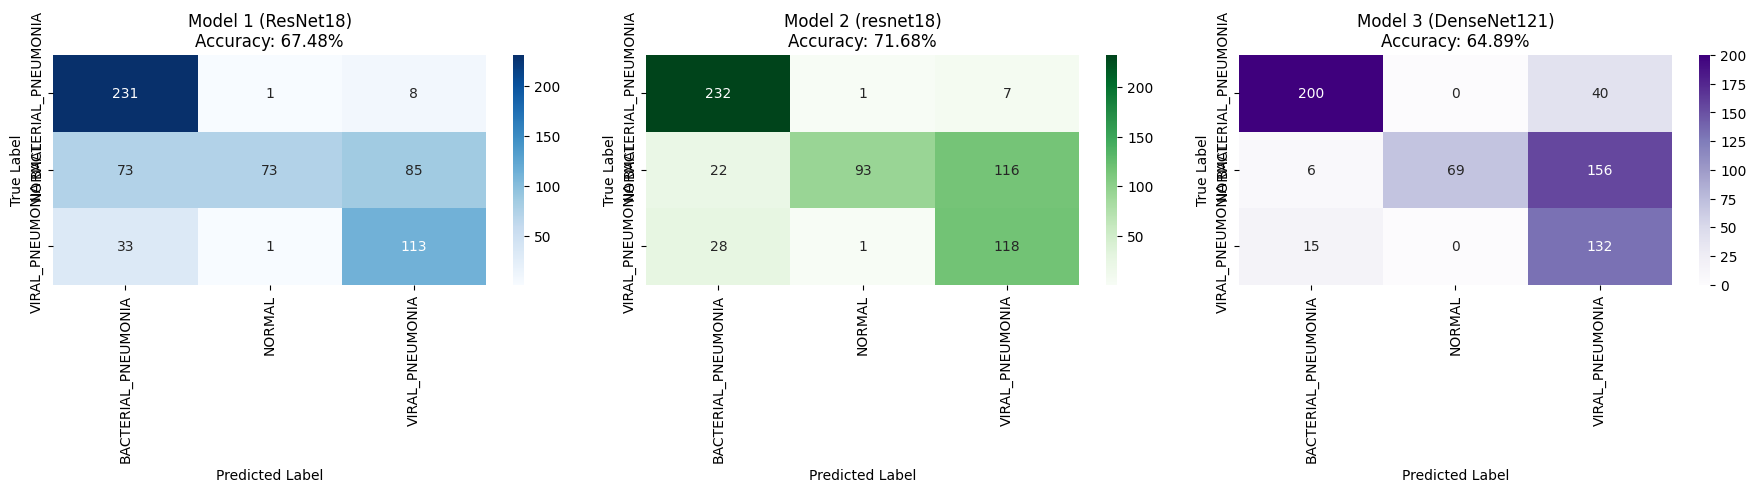


PER-CLASS ACCURACY COMPARISON
BACTERIAL_PNEUMONIA        96.25%            96.67%            83.33%
NORMAL                     31.60%            40.26%            29.87%
VIRAL_PNEUMONIA            76.87%            80.27%            89.80%

RECOMMENDATION

Best performing model: Model 2 (resnet18)
Accuracy: 71.68%

Use pneumonia_model_v2.pth for inference.


In [ ]:
# Side-by-side comparison of all 3 models
print("="*70)
print("MODEL COMPARISON SUMMARY")
print("="*70)

# Store Model 3 results
model3_best_acc = best_acc_v3
model3_train_losses = train_losses_v3.copy()
model3_val_losses = val_losses_v3.copy()
model3_train_accs = train_accs_v3.copy()
model3_val_accs = val_accs_v3.copy()
model3_predictions = predictions_v3.copy()

print(f"\n{'Metric':<25} {'Model 1':<18} {'Model 2':<18} {'Model 3':<18}")
print("-"*80)
print(f"{'Architecture':<25} {'ResNet18':<18} {model2_architecture:<18} {'DenseNet121':<18}")
print(f"{'Best Accuracy':<25} {model1_best_acc:.2f}%{'':<12} {model2_best_acc:.2f}%{'':<12} {model3_best_acc:.2f}%")
print(f"{'Epochs Trained':<25} {len(model1_train_losses):<18} {len(model2_train_losses):<18} {len(model3_train_losses):<18}")
print(f"{'Scheduler':<25} {'StepLR':<18} {'CosineAnnealing':<18} {'CosineAnnealing':<18}")
print(f"{'Trainable Layers':<25} {'Last 10 params':<18} {'layer4 + fc':<18} {'denseblock4 + fc':<18}")
print(f"{'Enhanced Augmentation':<25} {'OFF':<18} {'ON':<18} {'ON':<18}")
print(f"{'MixUp':<25} {'OFF':<18} {'ON':<18} {'ON':<18}")

# Visual comparison of validation accuracy curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison over epochs
ax1 = axes[0]
epochs1 = range(1, len(model1_val_accs) + 1)
epochs2 = range(1, len(model2_val_accs) + 1)
epochs3 = range(1, len(model3_val_accs) + 1)
ax1.plot(epochs1, model1_val_accs, 'b-o', label=f'Model 1 - ResNet18 (best: {model1_best_acc:.2f}%)', markersize=4)
ax1.plot(epochs2, model2_val_accs, 'g-o', label=f'Model 2 - {model2_architecture} (best: {model2_best_acc:.2f}%)', markersize=4)
ax1.plot(epochs3, model3_val_accs, 'm-o', label=f'Model 3 - DenseNet121 (best: {model3_best_acc:.2f}%)', markersize=4)
ax1.set_title('Validation Accuracy Comparison')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy (%)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Bar chart comparison
ax2 = axes[1]
models = ['Model 1\n(ResNet18)', f'Model 2\n({model2_architecture})', 'Model 3\n(DenseNet121)']
accuracies = [model1_best_acc, model2_best_acc, model3_best_acc]
colors = ['#3498db', '#2ecc71', '#9b59b6']
bars = ax2.bar(models, accuracies, color=colors, edgecolor='black', linewidth=1.2)
ax2.set_ylabel('Best Accuracy (%)')
ax2.set_title('Best Accuracy Comparison')
ax2.set_ylim([min(accuracies) - 5, max(accuracies) + 5])

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Side-by-side confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm1 = confusion_matrix(labels, model1_predictions)
cm2 = confusion_matrix(labels_v2, model2_predictions)
cm3 = confusion_matrix(labels_v3, model3_predictions)

sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=classes, yticklabels=classes)
axes[0].set_title(f'Model 1 (ResNet18)\nAccuracy: {model1_best_acc:.2f}%')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=classes, yticklabels=classes)
axes[1].set_title(f'Model 2 ({model2_architecture})\nAccuracy: {model2_best_acc:.2f}%')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

sns.heatmap(cm3, annot=True, fmt='d', cmap='Purples', ax=axes[2],
            xticklabels=classes, yticklabels=classes)
axes[2].set_title(f'Model 3 (DenseNet121)\nAccuracy: {model3_best_acc:.2f}%')
axes[2].set_ylabel('True Label')
axes[2].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# Per-class accuracy comparison
print("\n" + "="*70)
print("PER-CLASS ACCURACY COMPARISON")
print("="*70)

for i, class_name in enumerate(classes):
    acc1 = cm1[i, i] / cm1[i].sum() * 100
    acc2 = cm2[i, i] / cm2[i].sum() * 100
    acc3 = cm3[i, i] / cm3[i].sum() * 100
    print(f"{class_name:<25} {acc1:>6.2f}%{'':<10} {acc2:>6.2f}%{'':<10} {acc3:>6.2f}%")

# Recommendation
print("\n" + "="*70)
print("RECOMMENDATION")
print("="*70)
best_model_idx = np.argmax(accuracies)
best_model_names = ['Model 1 (ResNet18)', f'Model 2 ({model2_architecture})', 'Model 3 (DenseNet121)']
best_model_files = ['pneumonia_model.pth', 'pneumonia_model_v2.pth', 'pneumonia_model_v3.pth']

print(f"\nBest performing model: {best_model_names[best_model_idx]}")
print(f"Accuracy: {accuracies[best_model_idx]:.2f}%")
print(f"\nUse {best_model_files[best_model_idx]} for inference.")
print("="*70)

In [ ]:
# Download all trained models
from google.colab import files

print("Downloading Model 1 (ResNet18 - original)...")
files.download('/content/pneumonia_model.pth')

print(f"Downloading Model 2 ({model2_architecture} - improved)...")
files.download('/content/pneumonia_model_v2.pth')

print("Downloading Model 3 (DenseNet121)...")
files.download('/content/pneumonia_model_v3.pth')

print("\n" + "="*60)
print("All 3 models downloaded!")
print(f"Best model: {best_model_files[best_model_idx]} ({accuracies[best_model_idx]:.2f}%)")
print("="*60)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


All 3 models downloaded!
Best model: pneumonia_model_v2.pth (71.68%)
